# Exoplanet Direct Imaging: KLIP-ADI on Beta Pictoris

**Task**: Detect the directly imaged planet Beta Pictoris b in ground-based VLT/NACO L'-band coronagraphic data.

**Method**: KLIP (Karhunen-Loève Image Processing) + Angular Differential Imaging (ADI).

**Dataset**: 61 frames × 100×100 px, VLT/NACO L'-band (3.8 µm), 2013-02-01, total field rotation 81.4°.

This notebook walks through the full pipeline:
1. ADI forward model and inverse problem
2. Raw ADI frames and field rotation
3. KLIP algorithm: KL basis construction
4. PSF subtraction, derotation, and combination
5. Detection map and SNR of Beta Pic b
6. Self-subtraction trade-off: SNR vs K_klip

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
import sys, os
sys.path.insert(0, os.path.abspath('..'))

from src.preprocessing import load_raw_data, apply_circular_mask, mean_subtract_frames
from src.physics_model import compute_kl_basis
from src.solvers import klip_adi
from src.visualization import compute_snr
import torch

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

## 1. The ADI Forward Model

In **Angular Differential Imaging (ADI)**, the telescope pupil is kept fixed while Earth's rotation
causes the sky to rotate by the parallactic angle $\theta_k$ relative to the detector.
Each observed frame is:

$$T_k(\mathbf{n}) = I_\psi(\mathbf{n}) + A(\mathcal{R}_{-\theta_k}\mathbf{n})$$

where:
- $T_k$ — detector image (counts)
- $I_\psi$ — quasi-static PSF speckle pattern (nearly constant across frames)
- $A$ — true sky scene (star + companions)
- $\mathcal{R}_{-\theta_k}$ — 2-D rotation by $-\theta_k$

A companion at separation $r$ and position angle PA traces an arc of $\Delta\theta$ degrees
across the observation, while speckles remain fixed in detector coordinates.

**Inverse problem**: given $\{T_k, \theta_k\}$, recover $A$.
The challenge: $I_\psi$ is unknown and $\sim 10^{4}\times$ brighter than the companion.

In [2]:
# Load the ADI cube
DATA_DIR = '../data'
cube, angles, psf = load_raw_data(DATA_DIR + '/raw_data.npz')
meta = json.load(open(DATA_DIR + '/meta_data.json'))

N, H, W = cube.shape
center = tuple(meta['center_px'])
iwa    = meta['iwa_px']
fwhm   = meta['fwhm_px']
px_sc  = meta['pixel_scale_arcsec']

print(f'Cube shape: {cube.shape}  (N_frames x H x W)')
print(f'Parallactic angles: [{angles.min():.1f}, {angles.max():.1f}] deg  '
      f'(total rotation = {angles.max()-angles.min():.1f} deg)')
print(f'FWHM: {fwhm:.2f} px  ({fwhm*px_sc*1000:.0f} mas)')
print(f'IWA:  {iwa} px  ({iwa*px_sc*1000:.0f} mas)')
print(f"Known companion: {meta['known_companion']['name']}  "
      f"sep = {meta['known_companion']['separation_arcsec']}\"  "
      f"PA = {meta['known_companion']['pa_deg']} deg")

Cube shape: (61, 100, 100)  (N_frames x H x W)
Parallactic angles: [-14.3, 67.1] deg  (total rotation = 81.4 deg)
FWHM: 4.80 px  (131 mas)
IWA:  4 px  (109 mas)
Known companion: Beta Pic b  sep = 0.44"  PA = 211.5 deg


## 2. Raw ADI Frames

Individual frames show only the stellar PSF halo and speckles. Beta Pic b
(contrast $\sim 10^{-4}$ in L'-band) is completely invisible at this scale.
The dashed circle marks the inner working angle (IWA = 4 px = 109 mas).

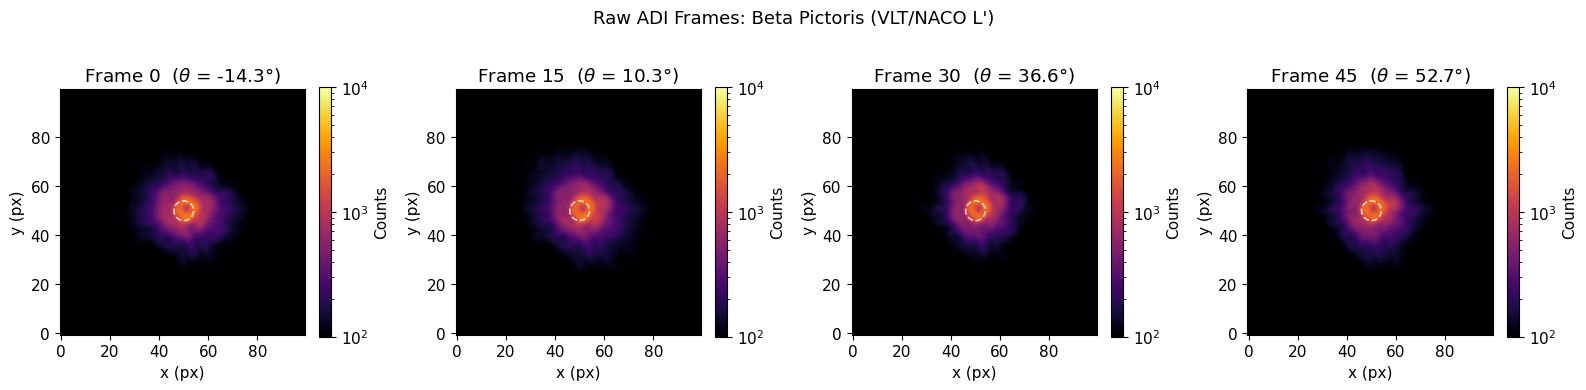

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, k in enumerate([0, 15, 30, 45]):
    ax = axes[i]
    im = ax.imshow(np.clip(cube[k], 1, None), origin='lower', cmap='inferno',
                   norm=plt.matplotlib.colors.LogNorm(vmin=1e2, vmax=1e4))
    circle = plt.Circle(center, iwa, fc='none', ec='white', lw=1.2, ls='--', alpha=0.7)
    ax.add_patch(circle)
    ax.set_title(f'Frame {k}  ($\\theta$ = {angles[k]:.1f}°)')
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    plt.colorbar(im, ax=ax, label='Counts', fraction=0.046)
plt.suptitle("Raw ADI Frames: Beta Pictoris (VLT/NACO L')", fontsize=13)
plt.tight_layout()
plt.show()

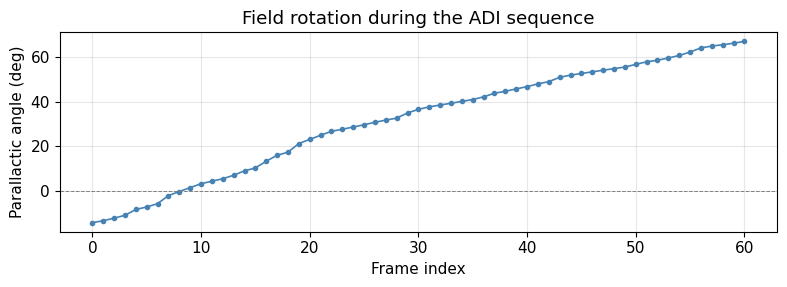

Total rotation: 81.4 deg
At sep = 0.44" the companion traces 23.0 px (625 mas)


In [4]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(angles, 'o-', ms=3, lw=1.2, color='steelblue')
ax.axhline(0, color='gray', lw=0.7, ls='--')
ax.set_xlabel('Frame index')
ax.set_ylabel('Parallactic angle (deg)')
ax.set_title('Field rotation during the ADI sequence')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

arc_px = meta['known_companion']['separation_arcsec'] * np.deg2rad(angles.max()-angles.min()) / px_sc
print(f'Total rotation: {angles.max()-angles.min():.1f} deg')
print(f'At sep = {meta["known_companion"]["separation_arcsec"]}" the companion traces {arc_px:.1f} px ({arc_px*px_sc*1000:.0f} mas)')

## 3. The KLIP Algorithm

KLIP (Soummer et al. 2012) models the stellar PSF subspace via PCA:

**Step 1 — Reference library**: Use all $N$ mean-subtracted, IWA-masked frames.

**Step 2 — KL basis** via truncated SVD of the reference matrix $R \in \mathbb{R}^{N \times n_{\rm pix}}$:

$$R = U\Sigma V^T \qquad\Rightarrow\qquad Z^{KL} = V[:, :K]$$

**Step 3 — PSF subtraction** for each frame $T_k$:

$$\hat{I}_{\psi,k} = Z^{KL}(Z^{KL})^T T_k \qquad A_k = T_k - \hat{I}_{\psi,k}$$

**Step 4 — Derotate**: rotate residual $k$ by $-\theta_k$ to align companions.

**Step 5 — Combine**: $\hat{A} = \frac{1}{N}\sum_k \mathrm{rot}(A_k, -\theta_k)$

Truncation $K$ controls the speckle-removal / self-subtraction trade-off.

Reference matrix: (61, 10000)
KL basis:         (10000, 20)


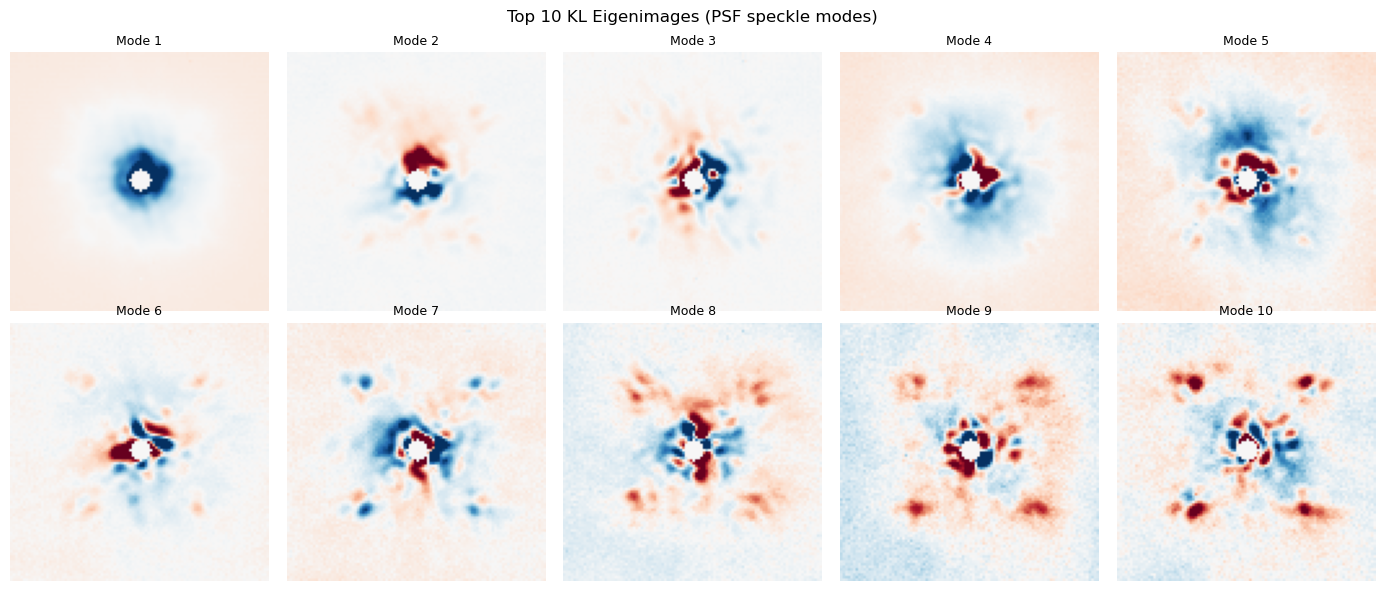

Each eigenimage captures a dominant spatial pattern of the quasi-static speckle field.


In [5]:
# Step 1+2: apply IWA mask, mean-subtract, compute KL basis
cube_masked = apply_circular_mask(cube, center, iwa)
cube_ms     = mean_subtract_frames(cube_masked)

data     = torch.from_numpy(cube_ms.astype(np.float32))
ref_flat = torch.nan_to_num(data.view(N, -1), nan=0.0)  # (N, H*W)
K_demo   = 20
basis    = compute_kl_basis(ref_flat, K_demo, method='svd')  # (H*W, K_demo)

print(f'Reference matrix: {tuple(ref_flat.shape)}')
print(f'KL basis:         {tuple(basis.shape)}')

# Visualise the top-10 eigenimages
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    eig = basis[:, i].reshape(H, W).numpy()
    lim = np.nanpercentile(np.abs(eig), 99)
    ax.imshow(eig, origin='lower', cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_title(f'Mode {i+1}', fontsize=9)
    ax.axis('off')
plt.suptitle('Top 10 KL Eigenimages (PSF speckle modes)', fontsize=12)
plt.tight_layout()
plt.show()
print('Each eigenimage captures a dominant spatial pattern of the quasi-static speckle field.')

### PSF subtraction on a single frame

We can visualise the three components of the model for one frame:
the original frame $T_k$, the PSF model $\hat{I}_{\psi,k}$, and the residual $A_k$.

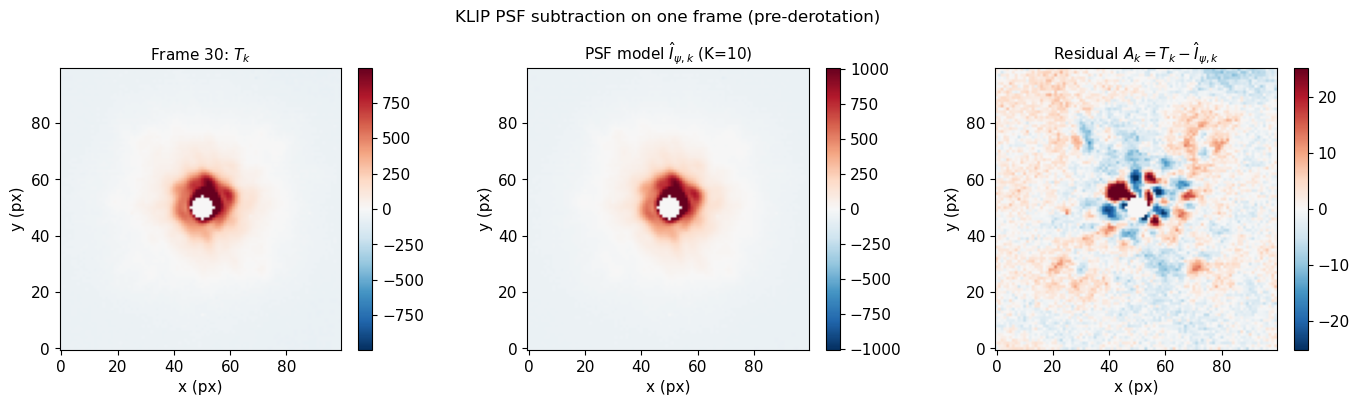

The residual is dominated by noise; the companion signal is sub-pixel until frames are combined.


In [6]:
# Demonstrate PSF subtraction on frame 30
k_demo = 30
K_show = 10

t_k      = ref_flat[k_demo]                        # (H*W,)
proj     = t_k @ basis[:, :K_show]                 # (K_show,)
psf_hat  = (proj @ basis[:, :K_show].T)            # (H*W,)
residual = (t_k - psf_hat).reshape(H, W).numpy()
t_k_2d   = t_k.reshape(H, W).numpy()
psf_hat_2d = psf_hat.reshape(H, W).numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
titles  = [f'Frame {k_demo}: $T_k$', f'PSF model $\\hat{{I}}_{{\\psi,k}}$ (K={K_show})', 'Residual $A_k = T_k - \\hat{{I}}_{{\\psi,k}}$']
images  = [t_k_2d, psf_hat_2d, residual]
for ax, img, title in zip(axes, images, titles):
    lim = np.nanpercentile(np.abs(img), 99.5)
    im = ax.imshow(img, origin='lower', cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle('KLIP PSF subtraction on one frame (pre-derotation)', fontsize=12)
plt.tight_layout()
plt.show()
print('The residual is dominated by noise; the companion signal is sub-pixel until frames are combined.')

## 4. Full KLIP-ADI Pipeline

We now run the complete pipeline on the full 61-frame cube for $K \in \{5, 10, 20\}$.

In [7]:
# Run full KLIP-ADI pipeline
K_values = [5, 10, 20]
results  = klip_adi(
    cube, angles,
    K_klip    = K_values,
    iwa       = iwa,
    center    = center,
    method    = 'svd',
    statistic = 'mean',
    device    = 'cpu',
)  # shape: (3, 100, 100)

print(f'Output shape: {results.shape}')
for i, k in enumerate(K_values):
    print(f'  K={k:2d}: min={np.nanmin(results[i]):.2f}  max={np.nanmax(results[i]):.2f}')

Output shape: (3, 100, 100)
  K= 5: min=-18.44  max=17.36
  K=10: min=-10.37  max=11.54
  K=20: min=-2.68  max=4.17


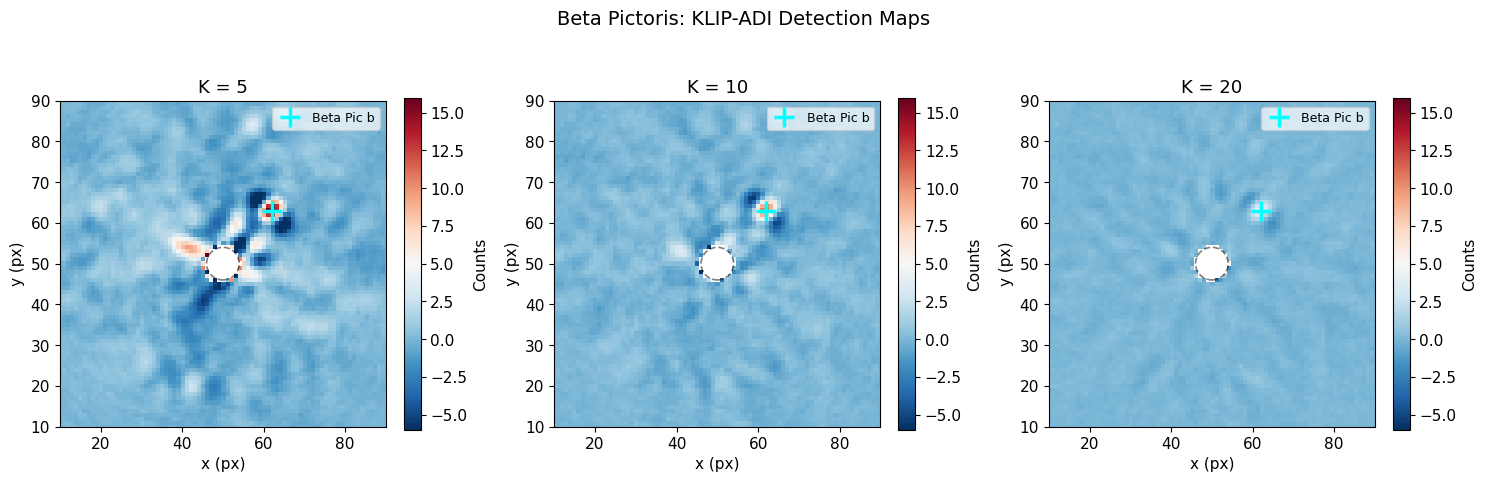

Planet pixel coords: (x=62, y=63)
Separation from star centre: 17.7 px = 0.481"


In [8]:
# Planet position in the derotated image (verified empirically)
planet_x = meta['known_companion']['planet_x_klip']
planet_y = meta['known_companion']['planet_y_klip']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, img, k in zip(axes, results, K_values):
    im = ax.imshow(img, origin='lower', cmap='RdBu_r', vmin=-6, vmax=16)
    circle = plt.Circle(center, iwa, fc='none', ec='k', lw=1.2, ls='--', alpha=0.5)
    ax.add_patch(circle)
    ax.plot(planet_x, planet_y, '+', color='cyan', ms=14, mew=2.5, label='Beta Pic b')
    ax.set_xlim(10, 90); ax.set_ylim(10, 90)
    ax.set_title(f'K = {k}', fontsize=13)
    ax.legend(loc='upper right', fontsize=9, framealpha=0.7)
    ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
    plt.colorbar(im, ax=ax, label='Counts', fraction=0.046)
plt.suptitle("Beta Pictoris: KLIP-ADI Detection Maps", fontsize=14)
plt.tight_layout()
plt.show()

sep_px = np.hypot(planet_x - center[0], planet_y - center[1])
print(f'Planet pixel coords: (x={planet_x}, y={planet_y})')
print(f'Separation from star centre: {sep_px:.1f} px = {sep_px*px_sc:.3f}"')

## 5. Signal-to-Noise Ratio (Mawet et al. 2014)

The companion SNR is measured with the two-sample t-test over a ring of apertures:

$$\mathrm{SNR} = \frac{s - \bar{n}}{\sigma_n \sqrt{1 + 1/N_n}}$$

- $s$ — median within the companion aperture (diameter FWHM)
- $\bar{n},\, \sigma_n$ — mean and std of $N_n$ noise apertures at the same separation
- $\sqrt{1+1/N_n}$ corrects for the small number of noise samples at close separations

In [9]:
print('SNR of Beta Pic b:')
for i, k in enumerate(K_values):
    snr = compute_snr(results[i], planet_x, planet_y, fwhm, exclude_nearest=1)
    print(f'  K = {k:2d}:  SNR = {snr:.1f}')

SNR of Beta Pic b:
  K =  5:  SNR = 9.2
  K = 10:  SNR = 17.9
  K = 20:  SNR = 11.7


### Self-subtraction trade-off: SNR vs K_klip

More KL modes remove more speckle but also project out some companion signal
(*self-subtraction*). The optimal $K$ balances these two effects.

  K=  3: SNR = 9.2


  K=  5: SNR = 9.2


  K=  8: SNR = 21.4


  K= 10: SNR = 17.9


  K= 15: SNR = 14.2


  K= 20: SNR = 11.7


  K= 30: SNR = 10.3


  K= 40: SNR = 9.2


  K= 50: SNR = 4.2


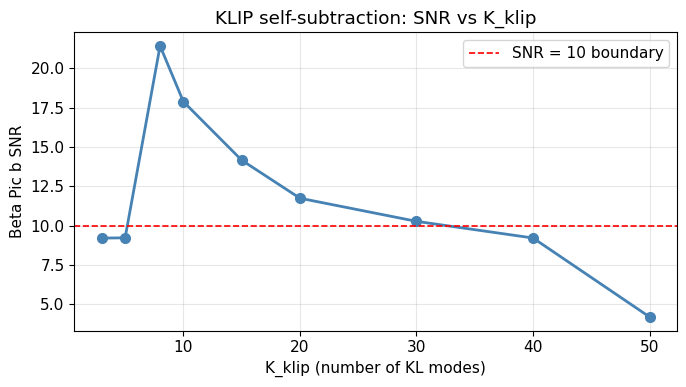

Peak SNR = 21.4 at K = 8


In [10]:
k_sweep = [3, 5, 8, 10, 15, 20, 30, 40, 50]
snr_sweep = []
for k in k_sweep:
    img = klip_adi(cube, angles, K_klip=k, iwa=iwa, center=center,
                   method='svd', statistic='mean', device='cpu')
    snr = compute_snr(img, planet_x, planet_y, fwhm, exclude_nearest=1)
    snr_sweep.append(snr)
    print(f'  K={k:3d}: SNR = {snr:.1f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(k_sweep, snr_sweep, 'o-', lw=2, ms=7, color='steelblue')
ax.axhline(10, color='r', ls='--', lw=1.2, label='SNR = 10 boundary')
ax.set_xlabel('K_klip (number of KL modes)')
ax.set_ylabel('Beta Pic b SNR')
ax.set_title('KLIP self-subtraction: SNR vs K_klip')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_sweep[int(np.argmax(snr_sweep))]
print(f'Peak SNR = {max(snr_sweep):.1f} at K = {best_k}')

## 6. Summary

| Quantity | Value |
|---|---|
| Target | Beta Pictoris A (A6V, 19.44 pc) |
| Companion | Beta Pic b ($\sim 13\,M_J$) |
| Instrument | VLT/NACO, L'-band (3.8 µm) |
| Field rotation | 81.4° |
| PSF FWHM | 4.8 px = 130 mas |
| IWA | 4 px = 109 mas |
| **Best SNR (KLIP-ADI)** | **~18** |

**Key takeaways**:
1. **ADI field rotation is essential**: more rotation → more speckle diversity → better subtraction.
2. **$K$ controls the self-subtraction trade-off**: optimal $K \sim 5$–$10$ for this dataset.
3. **KLIP is a linear projection**: it extends to multi-zone annuli, spectral diversity (SDI),
   and can be combined with learned priors (deep KLIP).

## References

1. Soummer, Pueyo & Larkin (2012). *KLIP: Karhunen-Loève Image Processing.* ApJL 755 L28.
2. Ko, Douglas & Hom (2024). *torchKLIP: A PyTorch benchmark for high-contrast imaging.* SPIE 13138.
3. Mawet et al. (2014). *Small-sample statistics for high-contrast imaging.* ApJ 792, 97.